# Summary of every experiment run

`survey_experiments.ipynb` asks *"what is in this set of runs?"* and diagnoses one run at a time.
This notebook asks the two questions that come after it:

1. **How did every experiment do**, on one page, at one common bet threshold — cross-validation
   win rate beside held-out win rate, for all three strategies.
2. **What is the effect of each variable on its own?** Not "run A beat run B", but "changing the
   training window from 3000 to 3750 games, with *nothing else different*, moved the win rate by
   this much" — and whether that is larger than the same configuration's own spread across seeds.

The second part is mechanical rather than curated. Every run's `config.json` is reduced to a
vector of **factors** (strategy, window, overtime handling, missingness budget, …), and two runs
form a *contrast* on factor X when they agree on every factor except X. Nothing is matched by
name or by campaign: `line_error_3750_anchor` is not a new configuration, it is a byte-for-byte
replication of `line_error_3750`, and only the config shows that.

**A run that changed two things at once appears in no contrast.** That is deliberate — it cannot
answer for either change.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Could not find the project root containing pyproject.toml.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from training_pipeline.reporting import charts, factors, rescore, theme
from training_pipeline.reporting.discovery import load_runs

# ===========================================================================
# Everything ever run. Narrow it only if you mean to -- the point of this
# notebook is the whole set. Accepts an artifacts folder, a campaign config
# folder, a config file, or a single run directory.
SOURCES: list[str] = ["artifacts/experiments"]
ARTIFACTS_ROOT = "artifacts/experiments"

# --- the one bet threshold this whole notebook speaks at --------------------
# Each run froze its own threshold into its artifacts when it ran: the August
# campaigns used 2.0 points, the later ones 0.1. Left alone, those numbers sit
# in the same column measuring different things. These re-score every run from
# its raw predictions -- no re-training involved -- so every comparison below
# is like-for-like.
#
# Units differ by strategy and one number cannot serve both:
#   EDGE -- regressors, |prediction - line| in points
#   EV   -- classifiers, expected value per unit staked
RESCORE_EDGE_THRESHOLD: float | None = 0.5

# Why the classifier's number is negative. It bets when max(EV_over, EV_under)
# exceeds the threshold, and at -110 the break-even probability is
# 1/1.909 = 52.38%. So `EV > 0` is not a permissive filter at all -- it is a
# hard "must be 52.4% confident" rule, and it was silently withholding a bet on
# 37-63% of games. That score bottoms out at -0.04545 (reached when p_over is
# exactly 0.500), so any threshold below that admits every game and leaves the
# dead zone empty:
#
#   -0.045  -> 99-100% of games bet -- near-empty dead zone (the default here)
#   -0.028  -> ~79%, which is what the regressors bet at EDGE 0.5 (volume-matched)
#    0.0    -> 37-63%, the old behaviour
#
# NOTE these two defaults are NOT volume-matched: at EDGE 0.5 the regressors sit
# out ~21% of games while the classifier sits out ~0%. That is the opposite of
# the old imbalance, not a fix for it. Use -0.028 for a like-for-like read.
RESCORE_EV_THRESHOLD: float | None = -0.045
# ===========================================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
theme.apply_theme()

runs = theme.prepare_runs(
    load_runs(SOURCES, artifacts_root=ARTIFACTS_ROOT, project_root=PROJECT_ROOT)
)
# Read each run's factor vector out of its config, then relabel every run by
# what actually makes it different ("line_error · 4500 · no-OT" rather than
# "line_error · 4500 [b3f1]"). Labelling happens before re-scoring because
# re-scoring joins on the label.
runs = factors.describe_labels(runs)

# Keep the threshold each run was SAVED at before re-scoring overwrites it.
# seed_stability.csv is computed at that threshold and cannot be re-scored --
# it stores per-seed summaries, not per-seed predictions -- so the seed range
# in section 3 belongs to this column, not to the one set above. See section 3.
runs["seed_threshold"] = runs["bet_min_edge"]

saved_thresholds = sorted(runs["bet_min_edge"].dropna().unique())
rescored = rescore.rescore_runs(
    runs, edge_threshold=RESCORE_EDGE_THRESHOLD, ev_threshold=RESCORE_EV_THRESHOLD
)
runs = rescore.apply_rescored(runs, rescored)
runs = factors.flag_cohorts(runs)

show = lambda messages: [display(Markdown(m)) for m in messages]   # noqa: E731

print(f"{len(runs)} runs loaded.")
print(f"Re-scored at edge>{RESCORE_EDGE_THRESHOLD} (regressors), "
      f"EV>{RESCORE_EV_THRESHOLD} (classifiers).")
print(f"  thresholds as saved were: {saved_thresholds}")
if missing := set(runs["label"]) - set(rescored["label"]):
    # Named, never silent: a run dropped from the re-scoring keeps reporting
    # its own frozen threshold in a column that claims to be common.
    print(f"  NOT re-scored (no usable predictions): {sorted(missing)}")
print(f"Reference holdout period: {runs.attrs['reference_cohort']}")
print("")
print("Resulting bet rate by strategy (the dead zone is 1 - bet_rate):")
print(runs[runs["cohort_ok"]].groupby("strategy_short")["bet_rate"]
      .agg(["min", "mean", "max"]).to_string(float_format="{:.1%}".format))

31 runs loaded.
Re-scored at edge>0.5 (regressors), EV>-0.045 (classifiers).
  thresholds as saved were: [np.float64(0.0), np.float64(0.1), np.float64(2.0)]
Reference holdout period: 2026-02-19 → 2026-04-17

Resulting bet rate by strategy (the dead zone is 1 - bet_rate):
                 min  mean    max
strategy_short                   
classifier     99.0% 99.4% 100.0%
line_error     68.8% 77.1%  83.7%
total_points   76.4% 80.6%  85.6%


## 1. What is comparable, and what is not

Two things have to hold before any two numbers below can be read against each other.

**Same holdout period.** ROI over 89 games in April–June is not a worse measurement of the same
thing as ROI over 416 games in February–April — it is a measurement of a *different season*. The
runs that kept playoffs, and the two earliest runs whose holdout starts later, are flagged here
and excluded from every controlled comparison. They are shown rather than deleted so it is clear
what was set aside and why.

The cohort test is on the holdout's **dates**, not its game count. The classifier scores 409 of
the same 416 games — seven it could not price, not a different two months — and a count-based
test would have thrown away the entire strategy comparison.

**Same threshold, in the right units.** All runs are re-scored above, but a regressor's `0.5`
means *points away from the line* while a classifier's `-0.045` means *expected value per unit
staked*. One number cannot serve both, and equal-looking numbers are not equal selectivity: the
old `EV > 0` reads like "no filter" and is really a hard 52.38%-confidence requirement.

So the column to watch is **`bet_rate`**, the only selectivity measure comparable across
strategies. At the thresholds set above it is roughly **79% for the regressors and ~100% for the
classifier** — the regressors are now the selective ones. That is a deliberate choice, not a
matched comparison; set `RESCORE_EV_THRESHOLD = -0.028` to equalise the two before reading §4 as
a verdict on strategy.

In [2]:
cohort = runs[["label", "holdout_window", "holdout_n_games", "n_bets", "bet_rate",
               "bet_min_edge", "cohort_ok", "cohort_note"]].sort_values(
    ["cohort_ok", "label"])
display(theme.percent_frame(cohort, percent=["bet_rate"]))

excluded = runs.loc[~runs["cohort_ok"], "label"].tolist()
display(Markdown(
    f"**{len(runs) - len(excluded)} of {len(runs)} runs** share the reference holdout period and "
    f"enter the comparisons below.\n\n"
    + ("**Set aside:** " + ", ".join(f"`{name}`" for name in excluded) if excluded
       else "Nothing set aside.")
))

,label,holdout_window,holdout_n_games,n_bets,bet_rate,bet_min_edge,cohort_ok,cohort_note
0,line_error · 2500 · weighted · 100trials,2026-03-07 → 2026-04-17,293,253,86.35%,0.500000,False,scored on 2026-03-07 → 2026-04-17
13,line_error · 4500 · +playoffs,2026-04-15 → 2026-06-13,89,62,69.66%,0.500000,False,scored on 2026-04-15 → 2026-06-13
23,total_points · 2500 · 100trials,2026-03-07 → 2026-04-17,293,244,83.28%,0.500000,False,scored on 2026-03-07 → 2026-04-17
22,total_points · 2500 · old-data · 100trials,2026-03-08 → 2026-04-17,287,240,83.62%,0.500000,False,scored on 2026-03-08 → 2026-04-17
17,classifier · 2500,2026-02-19 → 2026-04-17,409,409,100.00%,-0.045000,True,—
18,classifier · 3000,2026-02-19 → 2026-04-17,409,407,99.51%,-0.045000,True,—
19,classifier · 3750,2026-02-19 → 2026-04-17,409,406,99.27%,-0.045000,True,—
20,classifier · 3850,2026-02-19 → 2026-04-17,409,406,99.27%,-0.045000,True,—
21,classifier · 4500,2026-02-19 → 2026-04-17,409,405,99.02%,-0.045000,True,—
1,line_error · 2500,2026-02-19 → 2026-04-17,416,321,77.16%,0.500000,True,—


**27 of 31 runs** share the reference holdout period and enter the comparisons below.

**Set aside:** `line_error · 2500 · weighted · 100trials`, `line_error · 4500 · +playoffs`, `total_points · 2500 · old-data · 100trials`, `total_points · 2500 · 100trials`

## 2. Every run, one table

Cross-validation win rate beside held-out win rate, at the common threshold.

Read them as answering different questions and never average them. **CV** pools ~600 validation
games, but those are the folds that *chose* the hyperparameters, so it is optimistically biased —
use it to **rank**. **Holdout** is ~400 games never used for selection, so it is honest but thin
enough to be lucky — use it to **estimate**. Break-even at −110 is **52.38%**; the `edge` columns
are win rate minus that.

`cv_minus_holdout_roi` is the third number worth reading: a large gap in *either* direction says
the CV result did not transfer, which is the signature of selection overfitting.

In [3]:
SUMMARY_COLUMNS = [
    "label", "strategy_short", "train_games",
    "cv_win_rate", "cv_n_bets", "cv_roi",
    "win_rate", "n_bets", "bet_rate", "roi",
    "cv_minus_holdout_roi", "seed_roi_range", "n_seeds", "cohort_ok",
]
summary = runs[SUMMARY_COLUMNS].copy()
summary["cv_edge"] = summary["cv_win_rate"] - theme.BREAK_EVEN
summary["holdout_edge"] = summary["win_rate"] - theme.BREAK_EVEN
# Comparable runs first, then ROI. Sorting on ROI alone would interleave the
# runs scored on a different period into the ranking, which is the one thing
# the cohort flag exists to stop.
summary = summary.sort_values(
    ["cohort_ok", "roi"], ascending=[False, False]
).reset_index(drop=True)

display(theme.percent_frame(
    summary,
    percent=["cv_win_rate", "cv_roi", "win_rate", "bet_rate", "roi",
             "cv_minus_holdout_roi", "seed_roi_range", "cv_edge", "holdout_edge"],
))

,label,strategy_short,train_games,cv_win_rate,cv_n_bets,cv_roi,win_rate,n_bets,bet_rate,roi,cv_minus_holdout_roi,seed_roi_range,n_seeds,cohort_ok,cv_edge,holdout_edge
0,line_error · 3750 (run 1),line_error,3750,54.96%,487.000000,4.89%,57.10%,321,77.16%,8.89%,-4.00%,6.19%,3.000000,True,2.58%,4.72%
1,line_error · 3750 (run 2),line_error,3750,54.96%,487.000000,4.89%,57.10%,321,77.16%,8.89%,-4.00%,5.88%,5.000000,True,2.58%,4.72%
2,line_error · 4500 · maxna120,line_error,4500,52.51%,481.000000,0.25%,56.96%,322,77.40%,8.58%,-8.34%,7.31%,3.000000,True,0.13%,4.58%
3,line_error · 2500,line_error,2500,52.52%,478.000000,0.27%,56.47%,321,77.16%,7.70%,-7.44%,10.10%,3.000000,True,0.14%,4.09%
4,line_error · 4500 · no-OT,line_error,4500,53.28%,520.000000,1.71%,56.35%,313,75.24%,7.44%,-5.72%,1.50%,3.000000,True,0.90%,3.97%
5,line_error · 3000,line_error,3000,54.17%,531.000000,3.39%,56.17%,331,79.57%,7.09%,-3.70%,10.55%,5.000000,True,1.79%,3.79%
6,line_error · 4500,line_error,4500,54.72%,521.000000,4.45%,55.72%,348,83.65%,6.24%,-1.79%,3.38%,3.000000,True,2.34%,3.34%
7,classifier · 4500,classifier,4500,51.86%,646.000000,-1.00%,55.56%,405,99.02%,6.06%,-7.06%,6.99%,3.000000,True,-0.52%,3.17%
8,total_points · 3750,total_points,3750,53.83%,564.000000,2.76%,55.30%,356,85.58%,5.46%,-2.71%,11.98%,3.000000,True,1.45%,2.92%
9,total_points · 4500 · no-OT,total_points,4500,51.48%,510.000000,-1.71%,54.86%,325,78.12%,4.64%,-6.35%,1.87%,3.000000,True,-0.90%,2.48%


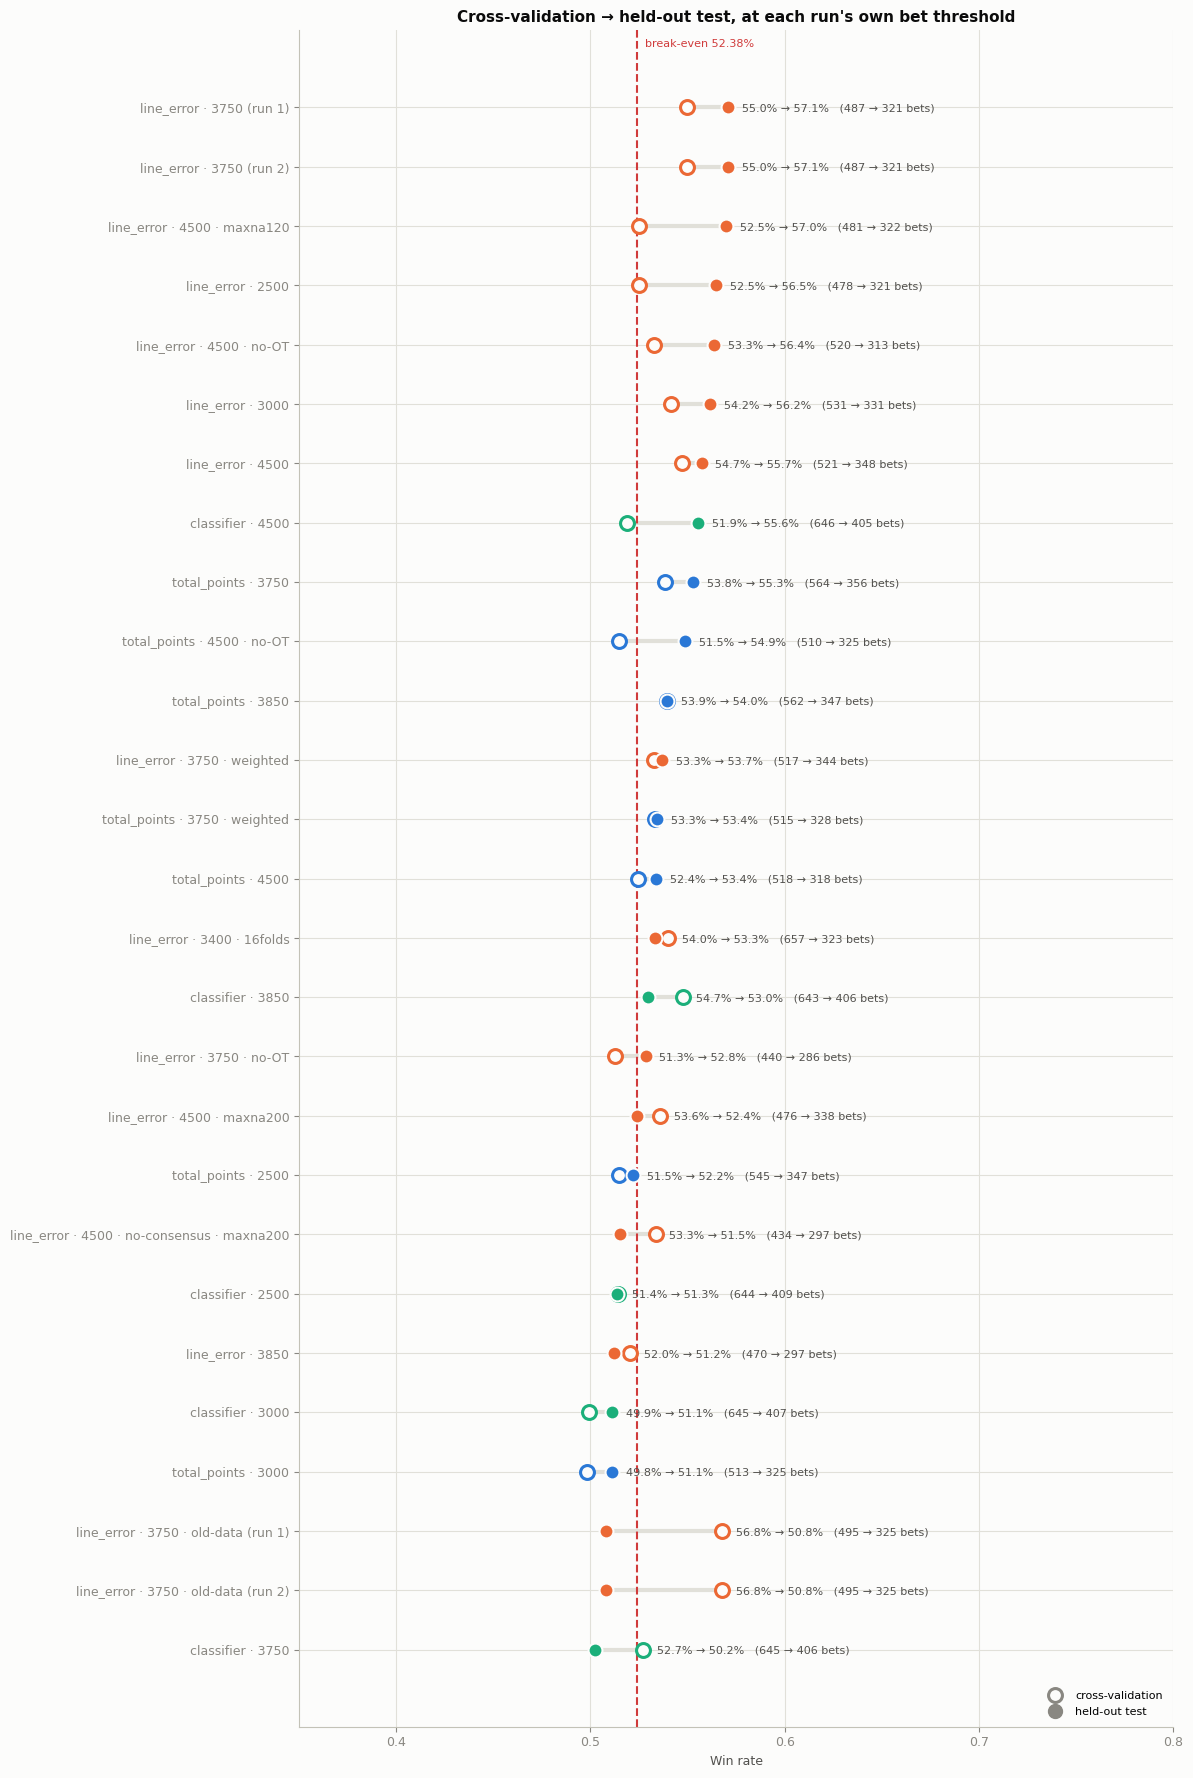

,label,prediction_strategy,holdout_evaluation,cv_win_rate,cv_n_bets,win_rate,n_bets,win_rate_drop,cv_roi,roi
0,line_error · 3750 (run 1),line_error_regressor,daily_walk_forward,0.549587,487.0,0.570978,321,-0.021391,0.048908,0.088927
1,line_error · 3750 (run 2),line_error_regressor,daily_walk_forward,0.549587,487.0,0.570978,321,-0.021391,0.048908,0.088927
2,line_error · 4500 · maxna120,line_error_regressor,daily_walk_forward,0.525105,481.0,0.569620,322,-0.044516,0.002457,0.085827
3,line_error · 2500,line_error_regressor,daily_walk_forward,0.525210,478.0,0.564669,321,-0.039459,0.002663,0.077032
4,line_error · 4500 · no-OT,line_error_regressor,daily_walk_forward,0.532819,520.0,0.563518,313,-0.030699,0.017133,0.074354
5,line_error · 3000,line_error_regressor,daily_walk_forward,0.541667,531.0,0.561728,331,-0.020062,0.033898,0.070860
6,line_error · 4500,line_error_regressor,daily_walk_forward,0.547206,521.0,0.557185,348,-0.009979,0.044495,0.062435
7,classifier · 4500,over_under_classifier,daily_walk_forward,0.518576,646.0,0.555556,405,-0.036980,-0.009992,0.060606
8,total_points · 3750,total_points_regressor,daily_walk_forward,0.538324,564.0,0.553009,356,-0.014684,0.027563,0.054648
9,total_points · 4500 · no-OT,total_points_regressor,daily_walk_forward,0.514793,510.0,0.548589,325,-0.033796,-0.017112,0.046434


In [4]:
# The same table as a picture: hollow = cross-validation, filled = holdout.
charts.plot_cv_vs_test_win_rate(runs[runs["cohort_ok"]])

## 3. The yardstick — how much moves for no reason at all

Before reading any difference as an effect, it needs something to be larger than.

Two sources of it are measured here. **Replicates** are configurations that were executed twice;
they are the cleanest possible control, since nothing whatsoever differs. **Seed range** is the
observed min–max of holdout ROI when the same configuration is refit with different random seeds,
with nothing else changed — an observed range, not a confidence interval, which is why it is drawn
as a plain rule below and not an error bar.

**One caveat that cannot be re-scored away.** Everything else in this notebook is recomputed at
the common threshold set in the setup cell, but the seed range cannot be: `seed_stability.csv`
stores per-seed *summaries*, not per-seed predictions, so its ROI is frozen at whatever threshold
each run was executed with (the `seed_threshold` column below — 0.1 or 2.0, never 0.5). The noise
floor is therefore measured on slightly different terms from the ROIs being compared against it.
It is still by far the best error bar available, and the direction of the distortion is knowable:
a threshold of 2.0 leaves ~90 bets rather than ~400, and ROI over fewer bets is noisier, so those
runs' ranges likely *overstate* the noise at 0.5. Treat the floor as an order of magnitude, not a
decision boundary.

The number printed here is the working noise floor for the rest of the notebook. **Any effect
smaller than it is indistinguishable from having run the same thing again**, and the `effect`
tables below carry a `beats_seed_noise` column that applies exactly that test.

In [5]:
replicated = factors.replicates(runs)
if replicated.empty:
    display(Markdown("_No configuration was run twice in this set._"))
else:
    display(Markdown(
        "**Replicates — same configuration, executed twice.** Identical metrics mean the "
        "pipeline is deterministic at a fixed seed, so these do *not* bound run-to-run noise; "
        "the seed range below is what does."
    ))
    display(theme.percent_frame(
        replicated[["label", "cv_win_rate", "win_rate", "roi", "seed_roi_range"]],
        percent=["cv_win_rate", "win_rate", "roi", "seed_roi_range"],
    ))

display(Markdown(
    "**Seed range per run, and the threshold it was frozen at.** These are not the threshold\n"
    "this notebook re-scores to; see the caveat above."
))
display(theme.percent_frame(
    runs[["label", "seed_threshold", "n_seeds", "seed_roi_range", "roi"]]
    .sort_values("seed_roi_range", ascending=False),
    percent=["seed_roi_range", "roi"],
))

seed_ranges = runs["seed_roi_range"].dropna()
NOISE_FLOOR = float(seed_ranges.median()) if not seed_ranges.empty else float("nan")
display(Markdown(
    f"**Seed range across {len(seed_ranges)} runs:** median **{NOISE_FLOOR:.1%}** of ROI, "
    f"worst **{seed_ranges.max():.1%}**, best **{seed_ranges.min():.1%}**.\n\n"
    f"> Treat **{NOISE_FLOOR:.0%} ROI** as the floor. Two runs differing by less than that "
    f"have not been shown to differ."
))

**Replicates — same configuration, executed twice.** Identical metrics mean the pipeline is deterministic at a fixed seed, so these do *not* bound run-to-run noise; the seed range below is what does.

,label,cv_win_rate,win_rate,roi,seed_roi_range
0,line_error · 3750 (run 1),54.96%,57.10%,8.89%,6.19%
1,line_error · 3750 (run 2),54.96%,57.10%,8.89%,5.88%
2,line_error · 3750 · old-data (run 1),56.80%,50.78%,-3.02%,4.30%
3,line_error · 3750 · old-data (run 2),56.80%,50.78%,-3.02%,6.48%


**Seed range per run, and the threshold it was frozen at.** These are not the threshold
this notebook re-scores to; see the caveat above.

,label,seed_threshold,n_seeds,seed_roi_range,roi
13,line_error · 4500 · +playoffs,0.100000,3.000000,29.62%,-10.70%
18,classifier · 3000,0.000000,5.000000,13.69%,-2.43%
26,total_points · 3750,2.000000,3.000000,11.98%,5.46%
2,line_error · 3000,0.100000,5.000000,10.55%,7.09%
1,line_error · 2500,2.000000,3.000000,10.10%,7.70%
17,classifier · 2500,0.000000,3.000000,9.09%,-1.98%
15,line_error · 4500 · no-consensus · maxna200,0.100000,3.000000,8.13%,-1.59%
10,line_error · 3850,0.100000,5.000000,8.02%,-2.23%
28,total_points · 3850,0.100000,5.000000,7.89%,2.96%
14,line_error · 4500 · maxna120,0.100000,3.000000,7.31%,8.58%


**Seed range across 28 runs:** median **6.3%** of ROI, worst **29.6%**, best **1.2%**.

> Treat **6% ROI** as the floor. Two runs differing by less than that have not been shown to differ.

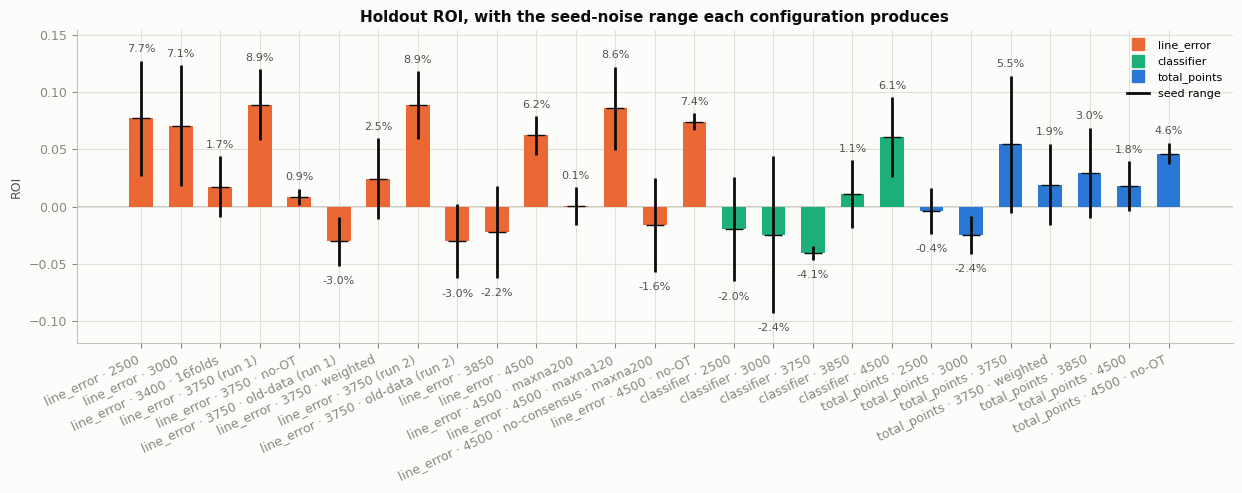

In [6]:
charts.plot_roi_with_seed_noise(runs[runs["cohort_ok"]])

## 4. Classifier vs regressors — matched on the training window

The comparison this set exists to make. All three strategies answer the same question (OVER or
UNDER this line) but spend their model capacity differently: the two regressors predict a number
and derive the bet, the classifier predicts P(OVER) directly. Each panel below holds the training
window fixed and varies only the strategy.

Two things to hold onto while reading it:

- **Bet volume is not matched at the default thresholds** (see §1). The classifier now bets on
  ~100% of games and the regressors on ~79%, so a win-rate gap here is partly a comparison of
  *how many* bets each placed, not only of how good they were. The annotated bet counts keep that
  visible; `RESCORE_EV_THRESHOLD = -0.028` removes it.
- **MAE cannot appear here.** It exists only for the regressors. ROI, win rate and bet volume are
  the only measures all three report, which is why the whole notebook is built on those.

Worth knowing about the classifier specifically: how often it bets is not a setting, it is a
by-product of how *spread out* its probabilities are, and that changes with the training window.
The 4500-game classifier keeps `p_over` inside 0.41–0.58 (std 0.027) where the 3750 one reaches
0.36–0.67 (std 0.047). Under the old `EV > 0` rule that alone swung its bet rate from 63% to 37%,
which is why its window effect in §5 was confounded. A near-empty dead zone removes that
confound.

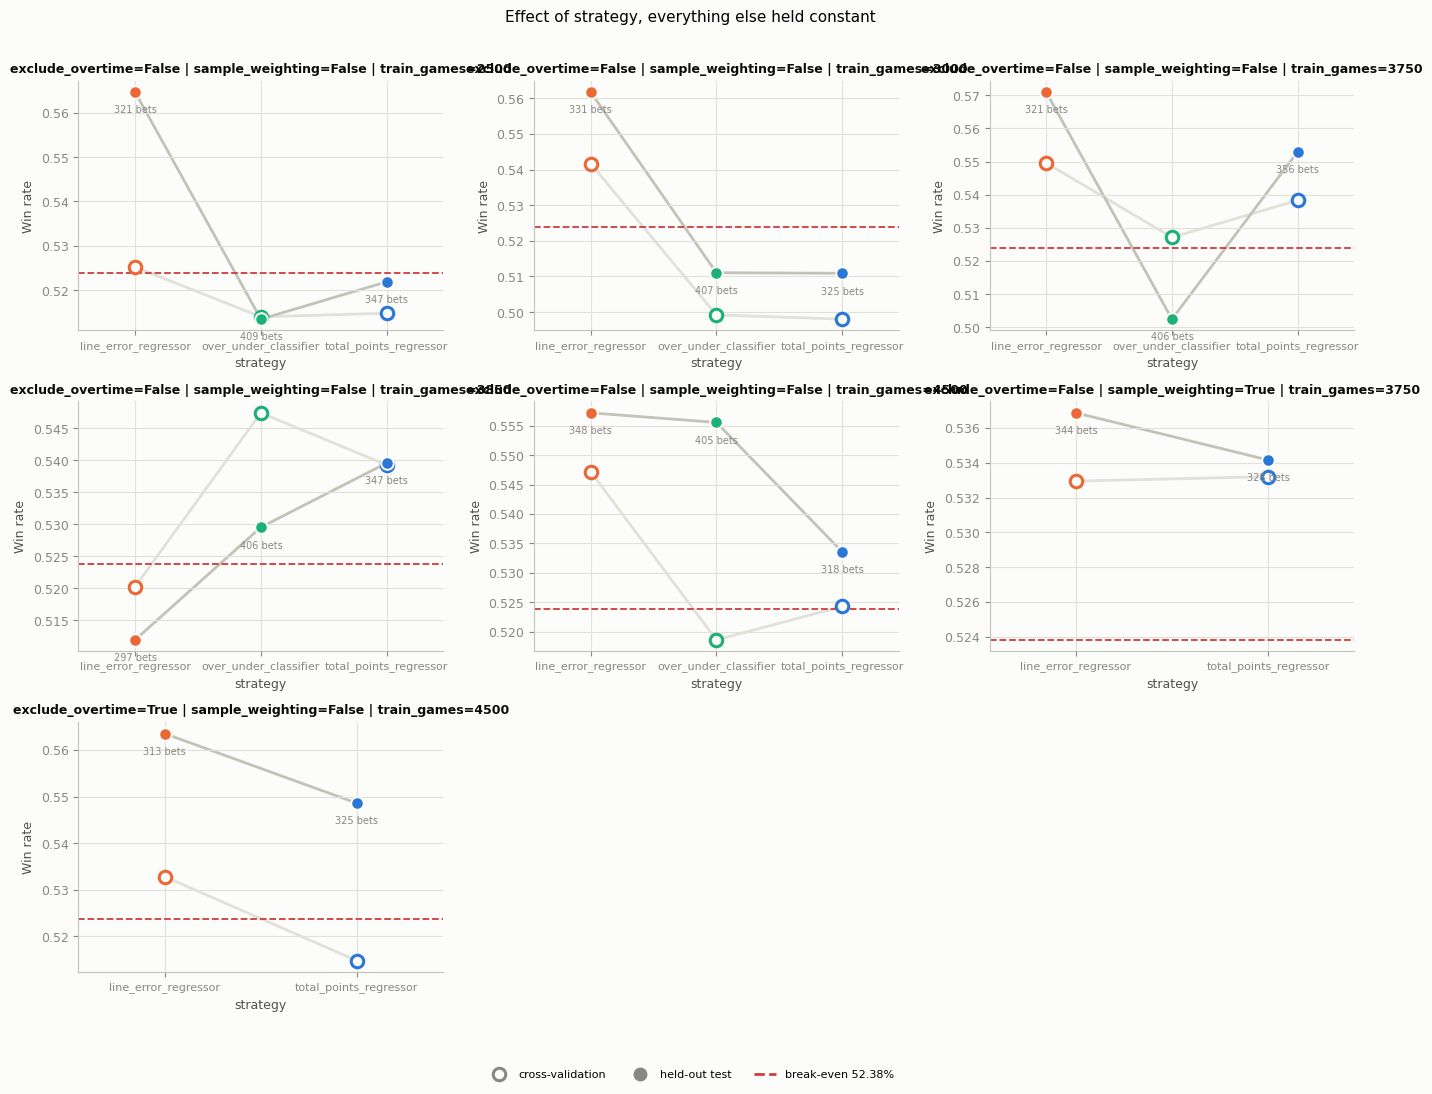

,contrast,label,cv_win_rate,cv_roi,win_rate,n_bets,bet_rate,roi
0,exclude_overtime=False | sample_weighting=False | train_games=2500,line_error · 2500,52.52%,0.27%,56.47%,321,77.16%,7.70%
1,exclude_overtime=False | sample_weighting=False | train_games=2500,classifier · 2500,51.40%,-1.88%,51.34%,409,100.00%,-1.98%
2,exclude_overtime=False | sample_weighting=False | train_games=2500,total_points · 2500,51.48%,-1.72%,52.19%,347,83.41%,-0.37%
3,exclude_overtime=False | sample_weighting=False | train_games=3000,line_error · 3000,54.17%,3.39%,56.17%,331,79.57%,7.09%
4,exclude_overtime=False | sample_weighting=False | train_games=3000,classifier · 3000,49.92%,-4.69%,51.11%,407,99.51%,-2.43%
5,exclude_overtime=False | sample_weighting=False | train_games=3000,total_points · 3000,49.80%,-4.91%,51.09%,325,78.12%,-2.43%
6,exclude_overtime=False | sample_weighting=False | train_games=3750,line_error · 3750 (run 1),54.96%,4.89%,57.10%,321,77.16%,8.89%
7,exclude_overtime=False | sample_weighting=False | train_games=3750,classifier · 3750,52.71%,0.63%,50.25%,406,99.27%,-4.08%
8,exclude_overtime=False | sample_weighting=False | train_games=3750,total_points · 3750,53.83%,2.76%,55.30%,356,85.58%,5.46%
9,exclude_overtime=False | sample_weighting=False | train_games=3850,line_error · 3850,52.03%,-0.68%,51.19%,297,71.39%,-2.23%


In [7]:
strategy_contrast = factors.contrasts(runs, "strategy")
charts.plot_factor_effect(strategy_contrast, "strategy")
display(theme.percent_frame(
    strategy_contrast[["contrast", "label", "cv_win_rate", "cv_roi",
                       "win_rate", "n_bets", "bet_rate", "roi"]],
    percent=["cv_win_rate", "cv_roi", "win_rate", "bet_rate", "roi"],
))

In [8]:
# Pooled across the matched windows: how each strategy does on average, and how
# much it swings. The spread matters as much as the mean -- a strategy whose
# best and worst matched runs are 15 ROI points apart has not been pinned down.
pooled = (
    strategy_contrast.groupby("strategy_short")
    .agg(matched_runs=("label", "count"),
         mean_cv_win_rate=("cv_win_rate", "mean"),
         mean_win_rate=("win_rate", "mean"),
         mean_roi=("roi", "mean"),
         worst_roi=("roi", "min"),
         best_roi=("roi", "max"),
         mean_bets=("n_bets", "mean"))
    .sort_values("mean_roi", ascending=False)
)
display(theme.percent_frame(
    pooled, percent=["mean_cv_win_rate", "mean_win_rate", "mean_roi",
                     "worst_roi", "best_roi"]))

,matched_runs,mean_cv_win_rate,mean_win_rate,mean_roi,worst_roi,best_roi,mean_bets
strategy_short,,,,,,,
line_error,7,53.57%,55.24%,5.37%,-2.23%,8.89%,325.000000
total_points,7,52.32%,53.45%,2.01%,-2.43%,5.46%,335.142857
classifier,5,52.13%,52.24%,-0.27%,-4.08%,6.06%,406.600000


## 5. Training window — the effect of *n* games, per strategy

Each panel is one strategy; the x-axis is the number of games in each training fold, with
everything else identical. This is the variable with the most cells behind it, and therefore the
one most exposed to multiple comparisons: **five window sizes across three strategies is fifteen
looks at the same noise**, so expect roughly one to look good by luck.

The right question is not "which window won" but "is there a trend?" — a real window effect should
move CV and holdout in the same direction and do so consistently across strategies.

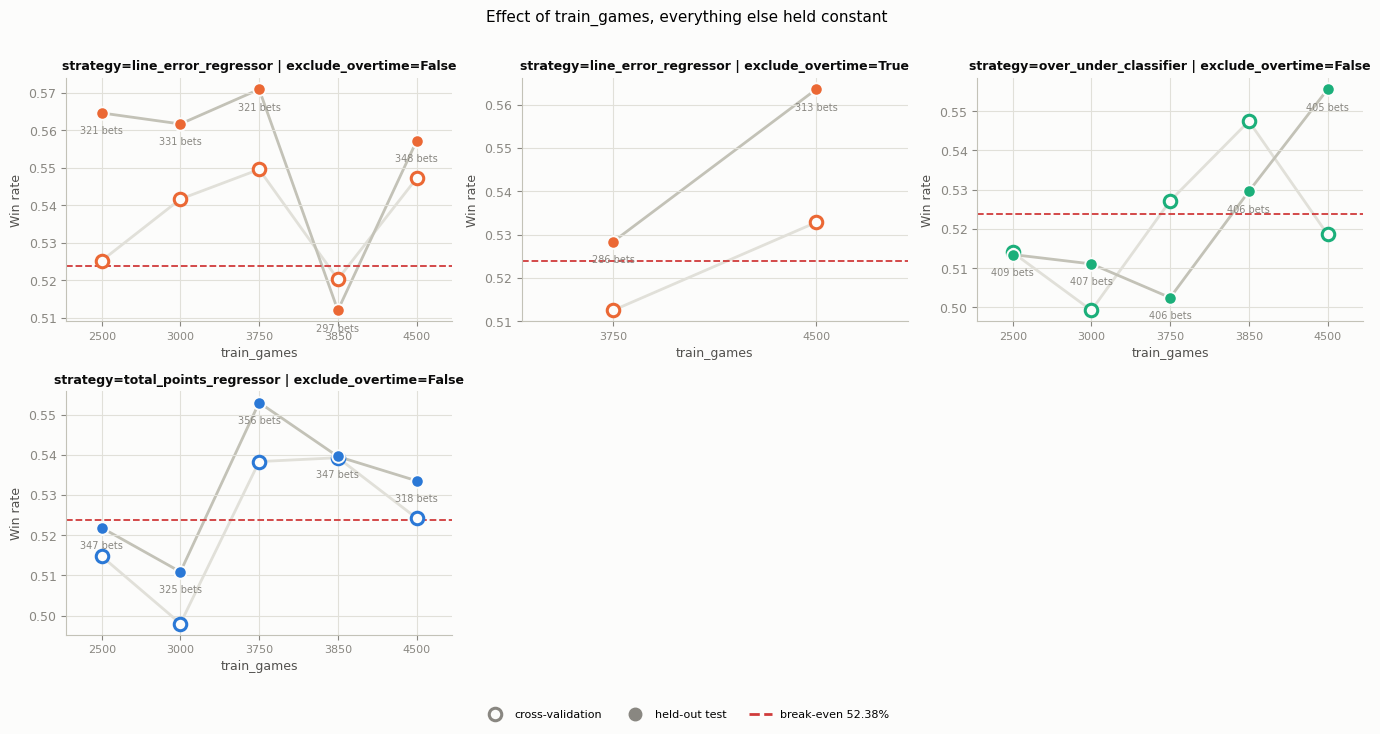

,contrast,train_games,label,cv_win_rate,cv_roi,win_rate,n_bets,roi,seed_roi_range
0,strategy=line_error_regressor | exclude_overtime=False,2500,line_error · 2500,52.52%,0.27%,56.47%,321,7.70%,10.10%
1,strategy=line_error_regressor | exclude_overtime=False,3000,line_error · 3000,54.17%,3.39%,56.17%,331,7.09%,10.55%
2,strategy=line_error_regressor | exclude_overtime=False,3750,line_error · 3750 (run 1),54.96%,4.89%,57.10%,321,8.89%,6.19%
3,strategy=line_error_regressor | exclude_overtime=False,3850,line_error · 3850,52.03%,-0.68%,51.19%,297,-2.23%,8.02%
4,strategy=line_error_regressor | exclude_overtime=False,4500,line_error · 4500,54.72%,4.45%,55.72%,348,6.24%,3.38%
5,strategy=line_error_regressor | exclude_overtime=True,3750,line_error · 3750 · no-OT,51.25%,-2.15%,52.84%,286,0.86%,1.47%
6,strategy=line_error_regressor | exclude_overtime=True,4500,line_error · 4500 · no-OT,53.28%,1.71%,56.35%,313,7.44%,1.50%
7,strategy=over_under_classifier | exclude_overtime=False,2500,classifier · 2500,51.40%,-1.88%,51.34%,409,-1.98%,9.09%
8,strategy=over_under_classifier | exclude_overtime=False,3000,classifier · 3000,49.92%,-4.69%,51.11%,407,-2.43%,13.69%
9,strategy=over_under_classifier | exclude_overtime=False,3750,classifier · 3750,52.71%,0.63%,50.25%,406,-4.08%,1.22%


In [9]:
window_contrast = factors.contrasts(runs, "train_games")
charts.plot_factor_effect(window_contrast, "train_games")
display(theme.percent_frame(
    window_contrast[["contrast", "train_games", "label", "cv_win_rate", "cv_roi",
                     "win_rate", "n_bets", "roi", "seed_roi_range"]],
    percent=["cv_win_rate", "cv_roi", "win_rate", "roi", "seed_roi_range"],
))

In [10]:
window_effect = factors.effect(window_contrast, "train_games")
display(theme.percent_frame(
    window_effect, percent=["d_cv_win_rate", "d_win_rate", "d_cv_roi", "d_roi",
                            "seed_roi_range"]))
display(Markdown(
    f"**{int(window_effect['beats_seed_noise'].sum())} of {len(window_effect)}** window changes "
    f"moved ROI by more than the configuration's own seed range."
))

,contrast,from,to,baseline_run,variant_run,d_cv_win_rate,d_win_rate,d_cv_roi,d_roi,seed_roi_range,beats_seed_noise
0,strategy=line_error_regressor | exclude_overtime=False,2500,3000,line_error · 2500,line_error · 3000,1.65%,-0.29%,3.12%,-0.62%,10.55%,False
1,strategy=line_error_regressor | exclude_overtime=False,2500,3750,line_error · 2500,line_error · 3750 (run 1),2.44%,0.63%,4.62%,1.19%,10.10%,False
2,strategy=line_error_regressor | exclude_overtime=False,2500,3850,line_error · 2500,line_error · 3850,-0.50%,-5.27%,-0.94%,-9.94%,10.10%,False
3,strategy=line_error_regressor | exclude_overtime=False,2500,4500,line_error · 2500,line_error · 4500,2.20%,-0.75%,4.18%,-1.46%,10.10%,False
4,strategy=line_error_regressor | exclude_overtime=True,3750,4500,line_error · 3750 · no-OT,line_error · 4500 · no-OT,2.03%,3.51%,3.86%,6.58%,1.50%,True
5,strategy=over_under_classifier | exclude_overtime=False,2500,3000,classifier · 2500,classifier · 3000,-1.48%,-0.24%,-2.82%,-0.46%,13.69%,False
6,strategy=over_under_classifier | exclude_overtime=False,2500,3750,classifier · 2500,classifier · 3750,1.32%,-1.10%,2.51%,-2.10%,9.09%,False
7,strategy=over_under_classifier | exclude_overtime=False,2500,3850,classifier · 2500,classifier · 3850,3.35%,1.61%,6.39%,3.08%,9.09%,False
8,strategy=over_under_classifier | exclude_overtime=False,2500,4500,classifier · 2500,classifier · 4500,0.46%,4.21%,0.88%,8.04%,9.09%,False
9,strategy=total_points_regressor | exclude_overtime=False,2500,3000,total_points · 2500,total_points · 3000,-1.67%,-1.10%,-3.19%,-2.07%,4.05%,False


**1 of 13** window changes moved ROI by more than the configuration's own seed range.

## 6. Everything else, one variable at a time

The remaining knobs that have been varied with a matched control. Each block is the same shape:
the matched runs, then the change in each metric relative to the block's baseline level, tested
against that configuration's own seed range.

- **`exclude_overtime`** — overtime games are 5.2% of the data and land +21 points over the line,
  85% OVER. Dropping them from *training* is a bet that they are unlearnable noise rather than
  signal. They stay in scoring either way; excluding them there would measure a world that
  does not exist.
- **`max_na_per_row`** — how many missing values a row may carry before it is dropped. This is the
  real missingness lever (`nan_threshold` was measured inert on the 2.0 build); raising it to 200
  recovers ~390 rows, mostly from season 2023 whose consensus-percentage columns are 62–85%
  missing. So it trades sample size against data quality.
- **`sample_weighting`** — exponential recency decay on training rows, with λ tuned by Optuna.
- **`data_build`** — the old feature CSV against the 2.0 build. The one comparison here that is
  about the *data* rather than the model.
- **`drop_consensus`** — removing the consensus-percentage columns entirely, tested on top of
  `max_na_per_row: 200`, i.e. against that variant rather than against the main baseline.

### Excluding overtime games from training — `exclude_overtime`

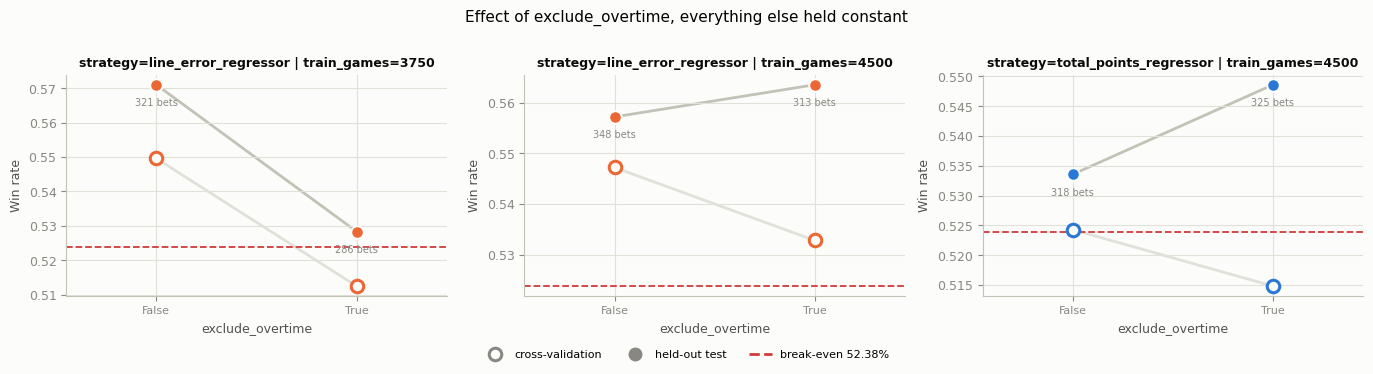

,contrast,exclude_overtime,label,cv_win_rate,cv_roi,win_rate,n_bets,roi
0,strategy=line_error_regressor | train_games=3750,False,line_error · 3750 (run 1),54.96%,4.89%,57.10%,321,8.89%
1,strategy=line_error_regressor | train_games=3750,True,line_error · 3750 · no-OT,51.25%,-2.15%,52.84%,286,0.86%
2,strategy=line_error_regressor | train_games=4500,False,line_error · 4500,54.72%,4.45%,55.72%,348,6.24%
3,strategy=line_error_regressor | train_games=4500,True,line_error · 4500 · no-OT,53.28%,1.71%,56.35%,313,7.44%
4,strategy=total_points_regressor | train_games=4500,False,total_points · 4500,52.43%,0.09%,53.35%,318,1.83%
5,strategy=total_points_regressor | train_games=4500,True,total_points · 4500 · no-OT,51.48%,-1.71%,54.86%,325,4.64%


,contrast,from,to,baseline_run,variant_run,d_cv_win_rate,d_win_rate,d_cv_roi,d_roi,seed_roi_range,beats_seed_noise
0,strategy=line_error_regressor | train_games=3750,False,True,line_error · 3750 (run 1),line_error · 3750 · no-OT,-3.71%,-4.26%,-7.04%,-8.03%,6.19%,True
1,strategy=line_error_regressor | train_games=4500,False,True,line_error · 4500,line_error · 4500 · no-OT,-1.44%,0.63%,-2.74%,1.19%,3.38%,False
2,strategy=total_points_regressor | train_games=4500,False,True,total_points · 4500,total_points · 4500 · no-OT,-0.95%,1.50%,-1.80%,2.81%,4.33%,False


### Missing-value budget per row — `max_na_per_row`

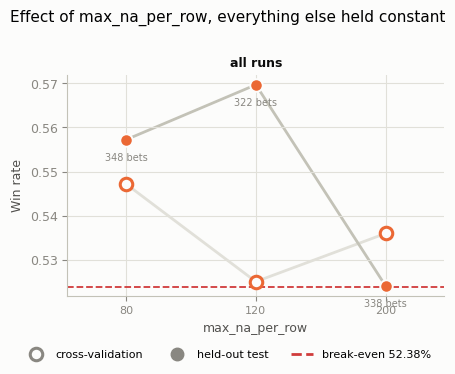

,contrast,max_na_per_row,label,cv_win_rate,cv_roi,win_rate,n_bets,roi
0,all runs,80,line_error · 4500,54.72%,4.45%,55.72%,348,6.24%
1,all runs,120,line_error · 4500 · maxna120,52.51%,0.25%,56.96%,322,8.58%
2,all runs,200,line_error · 4500 · maxna200,53.60%,2.31%,52.41%,338,0.05%


,contrast,from,to,baseline_run,variant_run,d_cv_win_rate,d_win_rate,d_cv_roi,d_roi,seed_roi_range,beats_seed_noise
0,all runs,80,120,line_error · 4500,line_error · 4500 · maxna120,-2.21%,1.24%,-4.20%,2.34%,7.31%,False
1,all runs,80,200,line_error · 4500,line_error · 4500 · maxna200,-1.12%,-3.31%,-2.14%,-6.19%,3.38%,True


### Recency weighting of training rows — `sample_weighting`

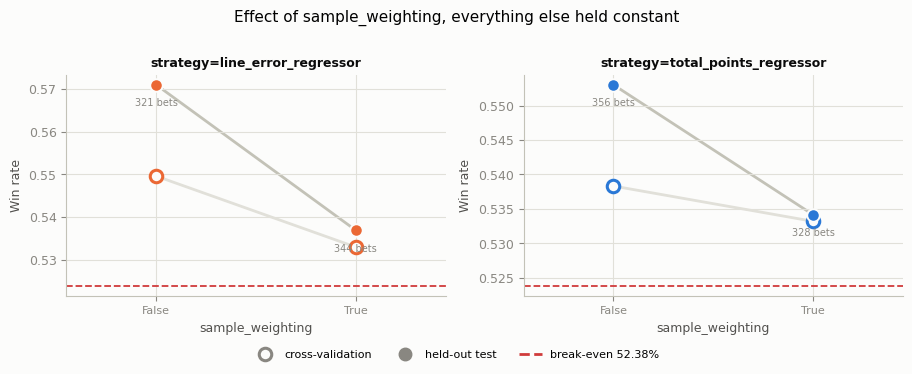

,contrast,sample_weighting,label,cv_win_rate,cv_roi,win_rate,n_bets,roi
0,strategy=line_error_regressor,False,line_error · 3750 (run 1),54.96%,4.89%,57.10%,321,8.89%
1,strategy=line_error_regressor,True,line_error · 3750 · weighted,53.29%,1.74%,53.69%,344,2.46%
2,strategy=total_points_regressor,False,total_points · 3750,53.83%,2.76%,55.30%,356,5.46%
3,strategy=total_points_regressor,True,total_points · 3750 · weighted,53.32%,1.78%,53.42%,328,1.94%


,contrast,from,to,baseline_run,variant_run,d_cv_win_rate,d_win_rate,d_cv_roi,d_roi,seed_roi_range,beats_seed_noise
0,strategy=line_error_regressor,False,True,line_error · 3750 (run 1),line_error · 3750 · weighted,-1.66%,-3.41%,-3.15%,-6.43%,7.04%,False
1,strategy=total_points_regressor,False,True,total_points · 3750,total_points · 3750 · weighted,-0.51%,-1.88%,-0.97%,-3.52%,11.98%,False


### Old feature build vs 2.0 — `data_build`

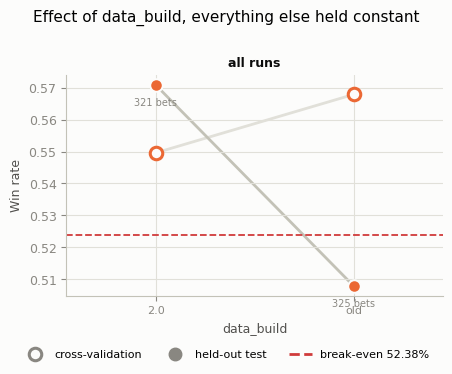

,contrast,data_build,label,cv_win_rate,cv_roi,win_rate,n_bets,roi
0,all runs,2.0,line_error · 3750 (run 1),54.96%,4.89%,57.10%,321,8.89%
1,all runs,old,line_error · 3750 · old-data (run 1),56.80%,8.39%,50.78%,325,-3.02%


,contrast,from,to,baseline_run,variant_run,d_cv_win_rate,d_win_rate,d_cv_roi,d_roi,seed_roi_range,beats_seed_noise
0,all runs,2.0,old,line_error · 3750 (run 1),line_error · 3750 · old-data (run 1),1.84%,-6.32%,3.50%,-11.91%,6.19%,True


### Dropping the consensus-percentage columns — `drop_consensus`

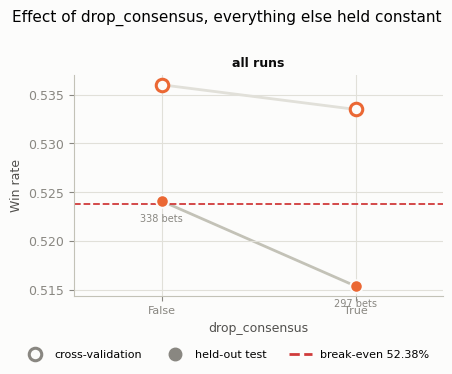

,contrast,drop_consensus,label,cv_win_rate,cv_roi,win_rate,n_bets,roi
0,all runs,False,line_error · 4500 · maxna200,53.60%,2.31%,52.41%,338,0.05%
1,all runs,True,line_error · 4500 · no-consensus · maxna200,53.35%,1.84%,51.54%,297,-1.59%


,contrast,from,to,baseline_run,variant_run,d_cv_win_rate,d_win_rate,d_cv_roi,d_roi,seed_roi_range,beats_seed_noise
0,all runs,False,True,line_error · 4500 · maxna200,line_error · 4500 · no-consensus · maxna200,-0.25%,-0.87%,-0.47%,-1.65%,8.13%,False


In [11]:
OTHER_FACTORS = [
    ("exclude_overtime", "Excluding overtime games from training"),
    ("max_na_per_row",   "Missing-value budget per row"),
    ("sample_weighting", "Recency weighting of training rows"),
    ("data_build",       "Old feature build vs 2.0"),
    ("drop_consensus",   "Dropping the consensus-percentage columns"),
]

for factor, title in OTHER_FACTORS:
    table = factors.contrasts(runs, factor)
    display(Markdown(f"### {title} — `{factor}`"))
    if table.empty:
        display(Markdown(
            "_No matched runs: nothing varies this factor with everything else held constant._"
        ))
        continue
    charts.plot_factor_effect(table, factor)
    display(theme.percent_frame(
        table[["contrast", factor, "label", "cv_win_rate", "cv_roi",
               "win_rate", "n_bets", "roi"]],
        percent=["cv_win_rate", "cv_roi", "win_rate", "roi"],
    ))
    display(theme.percent_frame(
        factors.effect(table, factor),
        percent=["d_cv_win_rate", "d_win_rate", "d_cv_roi", "d_roi", "seed_roi_range"],
    ))

## 7. What has *no* control

Runs that vary something nothing else varies, or that vary two things at once, cannot be
attributed to either change. They are not failures — they are the campaign telling you which
comparison to run next, and they are listed here so they are not mistaken for results.

In [12]:
matched = set()
for factor in [*factors.FACTOR_COLUMNS]:
    table = factors.contrasts(runs, factor)
    if not table.empty:
        matched |= set(table["run_name"])

unmatched = runs[~runs["run_name"].isin(matched)][
    ["label", "cohort_note", "cv_win_rate", "win_rate", "n_bets", "roi"]
]
if unmatched.empty:
    display(Markdown("_Every run sits in at least one controlled comparison._"))
else:
    display(theme.percent_frame(
        unmatched.sort_values("roi", ascending=False),
        percent=["cv_win_rate", "win_rate", "roi"]))

,label,cohort_note,cv_win_rate,win_rate,n_bets,roi
8,line_error · 3750 (run 2),—,54.96%,57.10%,321,8.89%
23,total_points · 2500 · 100trials,scored on 2026-03-07 → 2026-04-17,—,53.97%,244,2.98%
3,line_error · 3400 · 16folds,—,53.98%,53.31%,323,1.75%
0,line_error · 2500 · weighted · 100trials,scored on 2026-03-07 → 2026-04-17,52.79%,52.21%,253,-0.32%
22,total_points · 2500 · old-data · 100trials,scored on 2026-03-08 → 2026-04-17,—,51.49%,240,-1.67%
9,line_error · 3750 · old-data (run 2),—,56.80%,50.78%,325,-3.02%
13,line_error · 4500 · +playoffs,scored on 2026-04-15 → 2026-06-13,55.43%,46.77%,62,-10.70%


## 8. Best candidates so far

A shortlist, not a ranking. Three filters, applied in the order that each one invalidates the
next:

1. **Same holdout period** — otherwise the numbers are not about the same games.
2. **CV and holdout agree on the sign of the edge.** A run profitable in one and not the other has
   given no evidence that its edge transfers, whichever direction it points.
3. **Holdout ROI above the seed noise floor** from §3 — the edge has to be bigger than what a
   different random seed would have produced anyway.

Everything surviving all three should still be read as a *hypothesis to re-test*, not a result:
with ~30 runs against this noise floor, a couple of them clearing the bar by luck is the expected
outcome, not a surprise. The `win_rate_ci_low` column is the blunt version of that — where it sits
below 52.38%, the win rate is not distinguishable from break-even at this bet volume.

In [13]:
# One row per configuration, not per run: a config executed twice is one
# candidate, and listing it twice would make a shortlist of four look like it
# has more independent support than it does.
comparable = runs[runs["cohort_ok"]].drop_duplicates("design", keep="first")

candidates = comparable[
    (np.sign(comparable["cv_roi"]) == np.sign(comparable["roi"]))
    & (comparable["roi"] > NOISE_FLOOR)
].copy()

columns = ["label", "cv_win_rate", "cv_roi", "win_rate", "win_rate_ci_low",
           "n_bets", "bet_rate", "roi", "seed_roi_range", "cv_minus_holdout_roi"]
display(Markdown(
    f"**{len(candidates)} of {len(comparable)}** comparable configurations survive all three "
    f"filters (agreeing sign, holdout ROI > {NOISE_FLOOR:.1%})."
))
display(theme.percent_frame(
    candidates[columns].sort_values("roi", ascending=False),
    percent=["cv_win_rate", "cv_roi", "win_rate", "win_rate_ci_low", "bet_rate",
             "roi", "seed_roi_range", "cv_minus_holdout_roi"],
))

near_misses = comparable[~comparable["label"].isin(candidates["label"])]
display(Markdown("**Did not survive** — the filter each one failed:"))
reasons = pd.DataFrame({
    "label": near_misses["label"],
    "sign_disagreement": np.sign(near_misses["cv_roi"]) != np.sign(near_misses["roi"]),
    "roi_below_noise_floor": near_misses["roi"] <= NOISE_FLOOR,
    "roi": near_misses["roi"],
}).sort_values("roi", ascending=False)
display(theme.percent_frame(reasons, percent=["roi"]))

**5 of 25** comparable configurations survive all three filters (agreeing sign, holdout ROI > 6.3%).

,label,cv_win_rate,cv_roi,win_rate,win_rate_ci_low,n_bets,bet_rate,roi,seed_roi_range,cv_minus_holdout_roi
4,line_error · 3750 (run 1),54.96%,4.89%,57.10%,51.60%,321,77.16%,8.89%,6.19%,-4.00%
14,line_error · 4500 · maxna120,52.51%,0.25%,56.96%,51.45%,322,77.40%,8.58%,7.31%,-8.34%
1,line_error · 2500,52.52%,0.27%,56.47%,50.96%,321,77.16%,7.70%,10.10%,-7.44%
16,line_error · 4500 · no-OT,53.28%,1.71%,56.35%,50.76%,313,75.24%,7.44%,1.50%,-5.72%
2,line_error · 3000,54.17%,3.39%,56.17%,50.73%,331,79.57%,7.09%,10.55%,-3.70%


**Did not survive** — the filter each one failed:

,label,sign_disagreement,roi_below_noise_floor,roi
11,line_error · 4500,False,True,6.24%
21,classifier · 4500,True,True,6.06%
26,total_points · 3750,False,True,5.46%
30,total_points · 4500 · no-OT,True,True,4.64%
28,total_points · 3850,False,True,2.96%
7,line_error · 3750 · weighted,False,True,2.46%
27,total_points · 3750 · weighted,False,True,1.94%
29,total_points · 4500,False,True,1.83%
3,line_error · 3400 · 16folds,False,True,1.75%
20,classifier · 3850,False,True,1.10%


## Reading this — the order the questions come in

1. **Is the difference bigger than one run's own seed noise?** (§3) If not, stop; there is nothing
   to explain.
2. **Is there enough volume to conclude anything?** A 95% Wilson interval around a genuine 55% win
   rate needs roughly 1400 bets to clear 52.38%; nothing here has more than ~410. Read
   `win_rate_ci_low`, not `win_rate`.
3. **Do CV and the holdout agree?** A large gap in *either* direction is a warning.
4. **Is the comparison legitimate?** Same holdout cohort (§1), same threshold in the same units,
   comparable `bet_rate`, and nothing scored against a column the model was given as a feature.
5. **Only then, the result** — and only as a hypothesis for the next campaign.

**When new runs land**, re-run this notebook top to bottom. Every number, including the noise
floor and the candidate shortlist, is computed from the runs on disk; nothing is written down.
If a new campaign varies a knob not in `factors.FACTOR_SOURCES`, add it there — otherwise its
runs are matched as though they were identical, which is the quiet failure this notebook exists
to prevent.